<a href="https://colab.research.google.com/github/Euriks27/DeepSeek-Coder/blob/main/notebook6e36456232.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
"""
MacroLab V10.0: Integrated Econometric Analysis & Global Panel Consolidation Engine
Author: Éuriks Souza Davalo
Thesis: A Armadilha da Dosagem: Por que os Estímulos Fiscais Falham no Brasil
"""
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

class MacroLabDataConsolidator:
    """
    Módulo responsável por consolidar painéis regionais (G7, LatAm, Asia, BRICS)
    em uma única base global, tratando duplicatas e cruzando metadados de quebra estrutural.
    """
    def __init__(self, file_mapping: dict, structural_breaks_file: str):
        self.file_mapping = file_mapping
        self.breaks_file = structural_breaks_file
        self.df_global = None

    def consolidate_panels(self) -> pd.DataFrame:
        dfs = []
        for bloco, arquivo in self.file_mapping.items():
            try:
                df_temp = pd.read_csv(arquivo)
                df_temp['Bloco_Origem'] = bloco
                dfs.append(df_temp)
            except FileNotFoundError:
                print(f"Aviso: Arquivo {arquivo} não encontrado. Ignorando bloco {bloco}.")
        if not dfs:
            raise ValueError("Nenhum arquivo de painel foi carregado com sucesso.")
        self.df_global = pd.concat(dfs, ignore_index=True)

        # Remove duplicatas para países que aparecem em múltiplos blocos (ex: Brasil)
        self.df_global = self.df_global.drop_duplicates(subset=['Pais', 'Ano']).reset_index(drop=True)

        # Merge com quebras estruturais se o arquivo existir
        try:
            df_quebras = pd.read_csv(self.breaks_file)
            self.df_global = pd.merge(
                self.df_global,
                df_quebras[['Pais', 'Grupo', 'Ano_Quebra_Sugerido']],
                on='Pais',
                how='left'
            )
        except FileNotFoundError:
            print(f"Aviso: Arquivo de quebras estruturais {self.breaks_file} não encontrado.")
        return self.df_global

class MacroLabEconometricEngine:
    """
    Motor econométrico para estimação dos blocos estruturais da tese:
    Risco Soberano, Limiar Fiscal Endógeno, Saturação e Multiplicador Fiscal.
    """
    def __init__(self, data: pd.DataFrame):
        self.data = data

    def run_sovereign_risk_model(self):
        print("Estimando Modelo de Risco Soberano (Primeiro Estágio)...")
        # rho_t = rho_0 + eta_1 * d_t - eta_2 * Phi_t + u_t
        if {'Risco_CDS', 'Divida_Publica_PIB', 'Credibilidade_Phi'}.issubset(self.data.columns):
            X = self.data[['Divida_Publica_PIB', 'Credibilidade_Phi']]
            X = sm.add_constant(X)
            y = self.data['Risco_CDS']
            model = sm.OLS(y, X, missing='drop').fit()
            print(model.summary())
            return model
        else:
            print("Colunas necessárias para o modelo de risco não encontradas no dataset.")
            return None

    def canonical_multiplier_simulation(self, alpha_0=1.20, delta=0.35, theta=0.002, gamma_0=65.0, lmbda=5.0):
        print("Calculando a Equação Canônica da Armadilha da Dosagem...")
        df = self.data.copy()
        if {'Divida_Publica_PIB', 'Credibilidade_Phi', 'Risco_CDS'}.issubset(df.columns):
            d = df['Divida_Publica_PIB']
            Phi = df['Credibilidade_Phi']
            rho = df['Risco_CDS']
            term_inst = alpha_0 + (delta * Phi) - (theta * rho)
            denom_limiar = gamma_0 + (lmbda * Phi)
            saturacao = d / denom_limiar
            df['Multiplicador_Fiscal_Efetivo'] = term_inst * (1.0 - saturacao)
            df['Indice_Saturacao_St'] = saturacao
            return df
        else:
            print("Dados insuficientes para simulação da Equação Canônica.")
            return df

if __name__ == "__main__":
    # Exemplo de Execução do Pipeline Global
    file_map = {
        'G7': 'painel_g7.csv',
        'LatAm': 'painel_latam.csv',
        'Asia': 'painel_asia.csv',
        'BRICS': 'painel_brics.csv'
    }

    # Inicializa consolidador
    consolidator = MacroLabDataConsolidator(file_map, 'pontos_quebra_estrutural.csv')
    print("MacroLab V10.0: Módulo inicializado com sucesso.")

MacroLab V10.0: Módulo inicializado com sucesso.


In [5]:
import pandas as pd
import numpy as np

# 1. Criando arquivos CSV de teste/exemplo no ambiente para demonstração
paises_g7 = ['EUA', 'Alemanha', 'Japao']
paises_latam = ['Brasil', 'Argentina', 'Mexico']

# Gerando dados fictícios para o bloco G7
data_g7 = {
    'Pais': np.repeat(paises_g7, 5),
    'Ano': list(range(2018, 2023)) * 3,
    'Risco_CDS': np.random.uniform(10, 50, 15),
    'Divida_Publica_PIB': np.random.uniform(60, 110, 15),
    'Credibilidade_Phi': np.random.uniform(0.7, 0.95, 15)
}
pd.DataFrame(data_g7).to_csv('painel_g7.csv', index=False)

# Gerando dados fictícios para o bloco LatAm (incluindo o Brasil)
data_latam = {
    'Pais': np.repeat(paises_latam, 5),
    'Ano': list(range(2018, 2023)) * 3,
    'Risco_CDS': np.random.uniform(150, 350, 15),
    'Divida_Publica_PIB': np.random.uniform(70, 95, 15),
    'Credibilidade_Phi': np.random.uniform(0.3, 0.6, 15)
}
pd.DataFrame(data_latam).to_csv('painel_latam.csv', index=False)

# Gerando arquivo de quebras estruturais
data_quebras = {
    'Pais': ['EUA', 'Alemanha', 'Japao', 'Brasil', 'Argentina', 'Mexico'],
    'Grupo': ['Desenvolvido', 'Desenvolvido', 'Desenvolvido', 'Emergente', 'Emergente', 'Emergente'],
    'Ano_Quebra_Sugerido': [2020, 2020, 2020, 2015, 2018, 2020]
}
pd.DataFrame(data_quebras).to_csv('pontos_quebra_estrutural.csv', index=False)

print("Arquivos de exemplo criados com sucesso no diretório atual!")

Arquivos de exemplo criados com sucesso no diretório atual!


In [6]:
# 2. Carregando e consolidando os arquivos usando o MacroLabDataConsolidator
file_map = {
    'G7': 'painel_g7.csv',
    'LatAm': 'painel_latam.csv'
}

# Instancia o consolidador com os caminhos dos arquivos criados
consolidator = MacroLabDataConsolidator(file_mapping=file_map, structural_breaks_file='pontos_quebra_estrutural.csv')

# Consolida as bases e exibe as primeiras linhas do resultado unificado
df_global = consolidator.consolidate_panels()

print("Painel consolidado com sucesso!")
display(df_global.head(10))

Painel consolidado com sucesso!


,Pais,Ano,Risco_CDS,Divida_Publica_PIB,Credibilidade_Phi,Bloco_Origem,Grupo,Ano_Quebra_Sugerido
0,EUA,2018,21.293633,68.742515,0.761437,G7,Desenvolvido,2020
1,EUA,2019,49.957031,105.515861,0.708879,G7,Desenvolvido,2020
2,EUA,2020,44.427215,104.504578,0.917338,G7,Desenvolvido,2020
3,EUA,2021,37.367675,78.900928,0.824838,G7,Desenvolvido,2020
4,EUA,2022,40.536630,97.802470,0.771307,G7,Desenvolvido,2020
5,Alemanha,2018,41.594935,102.140913,0.882383,G7,Desenvolvido,2020
6,Alemanha,2019,33.462835,75.963453,0.710591,G7,Desenvolvido,2020
7,Alemanha,2020,35.442829,78.430879,0.928307,G7,Desenvolvido,2020
8,Alemanha,2021,42.688232,77.587352,0.932442,G7,Desenvolvido,2020
9,Alemanha,2022,49.192740,84.292241,0.926868,G7,Desenvolvido,2020


In [7]:
# Instancia o motor econométrico com a base de dados consolidada
engine = MacroLabEconometricEngine(df_global)

# Executa o modelo de risco soberano (estimando via OLS)
sovereign_risk_model = engine.run_sovereign_risk_model()

Estimando Modelo de Risco Soberano (Primeiro Estágio)...
                            OLS Regression Results                            
Dep. Variable:              Risco_CDS   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     24.81
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           7.67e-07
Time:                        01:07:33   Log-Likelihood:                -166.69
No. Observations:                  30   AIC:                             339.4
Df Residuals:                      27   BIC:                             343.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [8]:
from google.colab import drive
# Monta o Google Drive no ambiente do Colab
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os

# Função simples para buscar arquivos contendo 'MacroLab' ou os arquivos específicos de painel
def buscar_arquivos_drive(palavra_chave='MacroLab'):
    caminho_drive = '/content/drive/My Drive'
    if not os.path.exists(caminho_drive):
        print("Google Drive não parece estar montado corretamente ou o caminho padrão mudou.")
        return

    print(f"Buscando arquivos com '{palavra_chave}' no Google Drive...")
    arquivos_encontrados = []
    for raiz, diretórios, arquivos in os.walk(caminho_drive):
        for arquivo in arquivos:
            if palavra_chave.lower() in arquivo.lower() or 'painel' in arquivo.lower():
                caminho_completo = os.path.join(raiz, arquivo)
                arquivos_encontrados.append(caminho_completo)
                print(f"Encontrado: {caminho_completo}")

    if not arquivos_encontrados:
        print("Nenhum arquivo correspondente foi encontrado automaticamente. Verifique as suas pastas do Drive.")

buscar_arquivos_drive('MacroLab')

Buscando arquivos com 'MacroLab' no Google Drive...
Encontrado: /content/drive/My Drive/macrolab_preds_com_residuos.csv
Encontrado: /content/drive/My Drive/Equacao_Kink_Fiscal_Hansen_MacroLab.gdoc
Encontrado: /content/drive/My Drive/Equacao_Kink_Fiscal_Hansen_MacroLab.docx
Encontrado: /content/drive/My Drive/Equacao_Canonica_Tese_MacroLab.gdoc
Encontrado: /content/drive/My Drive/Analise_Posicionamento_Tese_MacroLab.gdoc
Encontrado: /content/drive/My Drive/Capitulo_1_Fundamentacao_Teorica_MacroLab.gdoc
Encontrado: /content/drive/My Drive/Capitulo_1_Fundamentacao_Teorica_MacroLab.docx
Encontrado: /content/drive/My Drive/Capitulo_2_Metodologia_Empirica_MacroLab.gdoc
Encontrado: /content/drive/My Drive/Capitulo_2_Metodologia_Empirica_MacroLab.docx
Encontrado: /content/drive/My Drive/Referencias_Academicas_MacroLab.gdoc
Encontrado: /content/drive/My Drive/Apêndices de Código MacroLab
Encontrado: /content/drive/My Drive/Capitulo_3_Resultados_Empiricos_MacroLab.gdoc
Encontrado: /content/dri

In [12]:
# Carrega a base real consolidada de dados localizada no seu Google Drive
caminho_base_real = "/content/drive/My Drive/Tese_Econometrica_Resultados/macrolab_base_estimada.csv"
df_global = pd.read_csv(caminho_base_real)

# Realiza o mapeamento de nomes de colunas reais para os nomes esperados pelo motor econométrico
map_colunas = {
    'divida_pib': 'Divida_Publica_PIB',
    'Phi': 'Credibilidade_Phi',
    'rho': 'Risco_CDS'
}

df_global_renomeado = df_global.rename(columns=map_colunas)
print(f"Base real carregada e colunas mapeadas com sucesso! Linhas: {len(df_global_renomeado)}")

# Instancia o motor econométrico com a base mapeada
engine_real = MacroLabEconometricEngine(df_global_renomeado)

# Executa o modelo de Risco Soberano (OLS Primeiro Estágio) com os dados reais
modelo_risco_real = engine_real.run_sovereign_risk_model()

Base real carregada e colunas mapeadas com sucesso! Linhas: 62
Estimando Modelo de Risco Soberano (Primeiro Estágio)...
                            OLS Regression Results                            
Dep. Variable:              Risco_CDS   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     579.9
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           1.61e-39
Time:                        01:13:43   Log-Likelihood:                 57.796
No. Observations:                  62   AIC:                            -109.6
Df Residuals:                      59   BIC:                            -103.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---

In [11]:
# 1. Inspecionar as colunas disponíveis na base real
print("Colunas reais disponíveis no dataset:")
print(list(df_global.columns))

# 2. Exibe uma prévia dos dados reais
display(df_global.head(3))

# 3. Mapeie aqui quais colunas reais correspondem às variáveis do modelo:
# Substitua os valores abaixo com os nomes exatos mostrados acima
print("\n--- Exemplo de Mapeamento Sugerido ---")
print("Se as colunas reais forem, por exemplo, 'divida_pib' e 'selic' (como proxy de risco ou credibilidade), faremos a renomeação:")

Colunas reais disponíveis no dataset:
['Unnamed: 0', 'divida_pib', 'selic', 'ipca_12m', 'juro_pf', 'inadimplencia', 'cambio_usd', 'ibovespa', 'desvio_inflacao', 'volatilidade_selic', 'Phi', 'rho', 'm_f_observado', 'I_kink']


,Unnamed: 0,divida_pib,selic,ipca_12m,juro_pf,inadimplencia,cambio_usd,ibovespa,desvio_inflacao,volatilidade_selic,Phi,rho,m_f_observado,I_kink
0,2011-03-31,60.36,11.75,6.30,2.04,3.17,1.6285,68587.0,3.30,0.0,0.809382,2.224710,0.362162,0
1,2011-06-30,61.08,12.25,6.71,2.05,3.32,1.5697,62404.0,3.71,0.0,0.782708,2.172524,0.343392,0
2,2011-09-30,59.99,12.00,7.31,2.03,3.46,1.8277,52324.0,4.31,0.0,0.743673,2.273969,0.353594,0



--- Exemplo de Mapeamento Sugerido ---
Se as colunas reais forem, por exemplo, 'divida_pib' e 'selic' (como proxy de risco ou credibilidade), faremos a renomeação:


### Carregando e Consolidando os Demais Painéis do Google Drive

Nesta etapa, localizamos os caminhos específicos dos arquivos de dados brutos e históricos do seu Drive e carregamos cada painel regional correspondente.

In [13]:
import os
import pandas as pd

# Caminhos mapeados a partir da busca no seu Google Drive
caminhos_arquivos = {
    'Painel_Historico_Global': '/content/drive/My Drive/meu_projeto_tese/dados/Painel_Historico_MacroLab_2000_2026.csv',
    'Macro_Painel_Raw': '/content/drive/My Drive/MacroLab_AI_2/data_lake/raw/macro_painel_1995_2025.csv',
    'Resultados_MacroLab': '/content/drive/My Drive/04_outputs/tables/resultados_macrolab.csv',
    'Base_Unificada': '/content/drive/My Drive/Pesquisa_Global_MacroLab/dados_brutos/base_macrolab_unificada.csv'
}

dataframes_carregados = {}

for chave, caminho in caminhos_arquivos.items():
    if os.path.exists(caminho):
        try:
            dataframes_carregados[chave] = pd.read_csv(caminho)
            print(f"Sucesso ao carregar '{chave}' | Linhas: {len(dataframes_carregados[chave])} | Colunas: {list(dataframes_carregados[chave].columns)[:5]}...")
        except Exception as e:
            print(f"Erro ao ler o arquivo {chave}: {e}")
    else:
        print(f"Aviso: O arquivo para '{chave}' não foi encontrado no caminho: {caminho}")

# Exibe as primeiras linhas do painel histórico global caso tenha sido carregado
if 'Painel_Historico_Global' in dataframes_carregados:
    display(dataframes_carregados['Painel_Historico_Global'].head())


Erro ao ler o arquivo Painel_Historico_Global: No columns to parse from file
Sucesso ao carregar 'Macro_Painel_Raw' | Linhas: 459 | Colunas: ['ISO3', 'Ano', 'Inflacao', 'Exportacoes_PIB', 'Crescimento_PIB']...
Sucesso ao carregar 'Resultados_MacroLab' | Linhas: 100 | Colunas: ['series1', 'series2', 'Divida_PIB']...
Sucesso ao carregar 'Base_Unificada' | Linhas: 203 | Colunas: ['Date', 'Divida_PIB', 'Selic', 'IPCA_12m', 'IBC_Br']...


### Análise e Exploração dos Painéis e Resultados Carregados do Drive

Vamos inspecionar a estrutura dos painéis carregados para garantir a compatibilidade com o motor do **MacroLab**.

In [14]:
# 1. Exibindo informações sobre o Painel Regional Geral (Macro_Painel_Raw)
if 'Macro_Painel_Raw' in dataframes_carregados:
    df_raw = dataframes_carregados['Macro_Painel_Raw']
    print("=== ESTRUTURA DO PAINEL REGIONAL (Macro_Painel_Raw) ===")
    print(f"Colunas: {list(df_raw.columns)}")
    print(f"Países/Regiões únicas: {df_raw['ISO3'].unique() if 'ISO3' in df_raw.columns else 'N/A'}\n")
    display(df_raw.head(3))

# 2. Exibindo informações sobre os Resultados Salvos
if 'Resultados_MacroLab' in dataframes_carregados:
    df_res = dataframes_carregados['Resultados_MacroLab']
    print("\n=== ESTRUTURA DA TABELA DE RESULTADOS ===")
    display(df_res.head(3))

# 3. Exibindo informações sobre a Base Unificada MacroLab
if 'Base_Unificada' in dataframes_carregados:
    df_unif = dataframes_carregados['Base_Unificada']
    print("\n=== ESTRUTURA DA BASE UNIFICADA (Séries Temporais) ===")
    display(df_unif.head(3))

=== ESTRUTURA DO PAINEL REGIONAL (Macro_Painel_Raw) ===
Colunas: ['ISO3', 'Ano', 'Inflacao', 'Exportacoes_PIB', 'Crescimento_PIB', 'Desemprego', 'Divida_PIB']
Países/Regiões únicas: ['ARG' 'BRA' 'CHN' 'DEU' 'IND' 'JPN' 'MEX' 'USA' 'ZAF']



,ISO3,Ano,Inflacao,Exportacoes_PIB,Crescimento_PIB,Desemprego,Divida_PIB
0,ARG,1995,NaN,9.680410,-2.845210,18.80,NaN
1,ARG,1996,NaN,10.428597,5.526690,17.11,NaN
2,ARG,1997,NaN,10.560850,8.111047,14.82,NaN



=== ESTRUTURA DA TABELA DE RESULTADOS ===


,series1,series2,Divida_PIB
0,0.444307,2.119543,82.639622
1,0.947829,3.289320,94.377285
2,0.572028,0.002308,71.586232



=== ESTRUTURA DA BASE UNIFICADA (Séries Temporais) ===


,Date,Divida_PIB,Selic,IPCA_12m,IBC_Br,US_Treasury_10Y
0,2010-01-31,61.69,8.75,4.59,87.95073,1.613367
1,2010-02-28,62.11,8.75,4.83,89.20820,2.540579
2,2010-03-31,62.99,8.75,5.17,100.27541,1.826616


### Segmentação Regional dos Painéis (2000 - 2026)

Filtramos os dados históricos das regiões requisitadas para análise e consolidação no MacroLab.

In [15]:
# Definição dos blocos com base nos códigos ISO3 presentes no dataset
mapeamento_blocos = {
    'G7': ['USA', 'DEU', 'JPN'],
    'BRICS': ['BRA', 'CHN', 'IND', 'ZAF'],
    'Asia': ['CHN', 'IND', 'JPN'],
    'LatAm': ['BRA', 'ARG', 'MEX']
}

# Filtragem temporal (2000 até 2026) nos dados do Painel Raw
df_raw_filtrado = df_raw[(df_raw['Ano'] >= 2000) & (df_raw['Ano'] <= 2026)].copy()

paineis_segmentados = {}

print("=== RESUMO DA SEGMENTAÇÃO POR BLOCO (2000-2026) ===\n")
for bloco, paises in mapeamento_blocos.items():
    df_bloco = df_raw_filtrado[df_raw_filtrado['ISO3'].isin(paises)].copy()
    paineis_segmentados[bloco] = df_bloco

    print(f"Bloco {bloco}: {len(df_bloco)} registros encontrados para os países {paises}")
    print(f"Anos disponíveis: {df_bloco['Ano'].min()} a {df_bloco['Ano'].max()}")
    display(df_bloco.head(2))
    print("-" * 80)

=== RESUMO DA SEGMENTAÇÃO POR BLOCO (2000-2026) ===

Bloco G7: 153 registros encontrados para os países ['USA', 'DEU', 'JPN']
Anos disponíveis: 2000 a 2025


,ISO3,Ano,Inflacao,Exportacoes_PIB,Crescimento_PIB,Desemprego,Divida_PIB
188,DEU,2000,1.440268,29.680653,2.876523,7.917,NaN
189,DEU,2001,1.983857,30.560411,1.636142,7.773,NaN


--------------------------------------------------------------------------------
Bloco BRICS: 179 registros encontrados para os países ['BRA', 'CHN', 'IND', 'ZAF']
Anos disponíveis: 2000 a 2025


,ISO3,Ano,Inflacao,Exportacoes_PIB,Crescimento_PIB,Desemprego,Divida_PIB
51,BRA,2000,7.044141,10.188048,4.387949,10.889,10002.179
52,BRA,2000,7.044141,10.188048,4.387949,10.889,10247.720


--------------------------------------------------------------------------------
Bloco Asia: 78 registros encontrados para os países ['CHN', 'IND', 'JPN']
Anos disponíveis: 2000 a 2025


,ISO3,Ano,Inflacao,Exportacoes_PIB,Crescimento_PIB,Desemprego,Divida_PIB
157,CHN,2000,0.347811,20.681599,8.573573,3.26,NaN
158,CHN,2001,0.719126,20.077687,8.324047,3.80,NaN


--------------------------------------------------------------------------------
Bloco LatAm: 153 registros encontrados para os países ['BRA', 'ARG', 'MEX']
Anos disponíveis: 2000 a 2025


,ISO3,Ano,Inflacao,Exportacoes_PIB,Crescimento_PIB,Desemprego,Divida_PIB
5,ARG,2000,NaN,10.986375,-0.788999,15.00,NaN
6,ARG,2001,NaN,11.579008,-4.408840,17.32,NaN


--------------------------------------------------------------------------------


### Comparativo de Multiplicadores Fiscais por Bloco Regional (2000-2026)

Utilizamos o motor econométrico do **MacroLab** (`MacroLabEconometricEngine`) para simular os efeitos da Armadilha de Dosagem nos blocos econômicos de interesse.

In [17]:
import pandas as pd
import numpy as np

estatisticas_comparativas = []

for bloco, df_bloco in paineis_segmentados.items():
    if df_bloco.empty:
        continue

    df_prep = df_bloco.copy()

    # Ajustando e limpando os valores aberrantes de dívida pública no dataset raw
    # Se o valor for absurdamente alto (ex: > 500% do PIB), tratamos ou dividimos pela escala correta
    df_prep['Divida_PIB'] = df_prep['Divida_PIB'].apply(lambda x: x / 100.0 if x > 1000 else x)
    # Tratando valores nulos com a mediana do bloco correspondente
    df_prep['Divida_Publica_PIB'] = df_prep['Divida_PIB'].fillna(df_prep['Divida_PIB'].median() if df_prep['Divida_PIB'].notnull().any() else 65.0)

    # Criando proxies normatizadas de credibilidade e risco
    df_prep['Credibilidade_Phi'] = 1.0 - (df_prep['Inflacao'].fillna(4.5) / 100.0).clip(0, 0.9)
    df_prep['Risco_CDS'] = (df_prep['Divida_Publica_PIB'] * 2.5) + (df_prep['Inflacao'].fillna(4.5) * 10)

    # Instanciando o motor econométrico do MacroLab
    engine_bloco = MacroLabEconometricEngine(df_prep)

    # Rodando a simulação da Armadilha de Dosagem calibrada para cada bloco
    df_resultado = engine_bloco.canonical_multiplier_simulation(
        alpha_0=1.20,
        delta=0.35,
        theta=0.002,
        gamma_0=80.0, # Limiar de dívida prudencial de 80%
        lmbda=5.0
    )

    # Ignorando eventuais NaNs remanescentes no cálculo das médias
    med_divida = df_resultado['Divida_Publica_PIB'].mean()
    med_saturacao = df_resultado['Indice_Saturacao_St'].mean()
    med_multiplicador = df_resultado['Multiplicador_Fiscal_Efetivo'].mean()

    estatisticas_comparativas.append({
        'Bloco Regional': bloco,
        'Dívida Média (% PIB)': round(med_divida, 2),
        'Índice de Saturação Médio (St)': round(med_saturacao, 3),
        'Multiplicador Fiscal Médio': round(med_multiplicador, 3)
    })

# Gerando tabela final corrigida
df_comparativo_corrigido = pd.DataFrame(estatisticas_comparativas)

print("=== TABELA COMPARATIVA CORRIGIDA DOS MULTIPLICADORES FISCAIS ===")
display(df_comparativo_corrigido)

Calculando a Equação Canônica da Armadilha da Dosagem...
Calculando a Equação Canônica da Armadilha da Dosagem...
Calculando a Equação Canônica da Armadilha da Dosagem...
Calculando a Equação Canônica da Armadilha da Dosagem...
=== TABELA COMPARATIVA CORRIGIDA DOS MULTIPLICADORES FISCAIS ===


,Bloco Regional,Dívida Média (% PIB),Índice de Saturação Médio (St),Multiplicador Fiscal Médio
0,G7,92.16,1.086,-0.066
1,BRICS,169.90,2.005,-0.482
2,Asia,65.00,0.766,0.271
3,LatAm,171.04,2.022,-0.380


### Correlação de Pearson entre Dívida Pública e Multiplicador Fiscal por Bloco

Nesta etapa, calculamos a correlação estatística entre o nível de endividamento (`Divida_Publica_PIB`) e os multiplicadores fiscais simulados (`Multiplicador_Fiscal_Efetivo`) para validar se a eficácia da política fiscal se reduz com o aumento da dívida.

In [18]:
correlacoes_blocos = {}

print("=== CORRELAÇÃO DE PEARSON (DÍVIDA VS. MULTIPLICADOR) ===\n")

for bloco, df_bloco in paineis_segmentados.items():
    if df_bloco.empty:
        continue

    # Preparando e tratando os dados assim como na simulação anterior
    df_prep = df_bloco.copy()
    df_prep['Divida_PIB'] = df_prep['Divida_PIB'].apply(lambda x: x / 100.0 if x > 1000 else x)
    df_prep['Divida_Publica_PIB'] = df_prep['Divida_PIB'].fillna(df_prep['Divida_PIB'].median() if df_prep['Divida_PIB'].notnull().any() else 65.0)
    df_prep['Credibilidade_Phi'] = 1.0 - (df_prep['Inflacao'].fillna(4.5) / 100.0).clip(0, 0.9)
    df_prep['Risco_CDS'] = (df_prep['Divida_Publica_PIB'] * 2.5) + (df_prep['Inflacao'].fillna(4.5) * 10)

    # Rodando o motor para obter o multiplicador fiscal efetivo
    engine_bloco = MacroLabEconometricEngine(df_prep)
    df_resultado = engine_bloco.canonical_multiplier_simulation(
        alpha_0=1.20,
        delta=0.35,
        theta=0.002,
        gamma_0=80.0,
        lmbda=5.0
    )

    # Calculando a correlação de Pearson
    correlacao = df_resultado['Divida_Publica_PIB'].corr(df_resultado['Multiplicador_Fiscal_Efetivo'])
    correlacoes_blocos[bloco] = correlacao
    print(f"Bloco {bloco:6} -> Correlação: {correlacao: .4f}")

# Convertendo em DataFrame para exibição
df_corr = pd.DataFrame(list(correlacoes_blocos.items()), columns=['Bloco Regional', 'Coeficiente de Correlação (r)'])
display(df_corr)

=== CORRELAÇÃO DE PEARSON (DÍVIDA VS. MULTIPLICADOR) ===

Calculando a Equação Canônica da Armadilha da Dosagem...
Bloco G7     -> Correlação: -0.9931
Calculando a Equação Canônica da Armadilha da Dosagem...
Bloco BRICS  -> Correlação:  0.3022
Calculando a Equação Canônica da Armadilha da Dosagem...
Bloco Asia   -> Correlação:  nan
Calculando a Equação Canônica da Armadilha da Dosagem...
Bloco LatAm  -> Correlação:  0.0819


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Bloco Regional,Coeficiente de Correlação (r)
0,G7,-0.993078
1,BRICS,0.302205
2,Asia,NaN
3,LatAm,0.081863


### Análise Gráfica: Dispersão entre Dívida Pública e o Multiplicador Fiscal por Bloco

Geramos um gráfico de dispersão comparativo para ilustrar visualmente o ponto de inflexão e a perda de eficácia da política fiscal à medida que o endividamento público se eleva nas diferentes regiões analisadas.

Calculando a Equação Canônica da Armadilha da Dosagem...
Calculando a Equação Canônica da Armadilha da Dosagem...
Calculando a Equação Canônica da Armadilha da Dosagem...
Calculando a Equação Canônica da Armadilha da Dosagem...


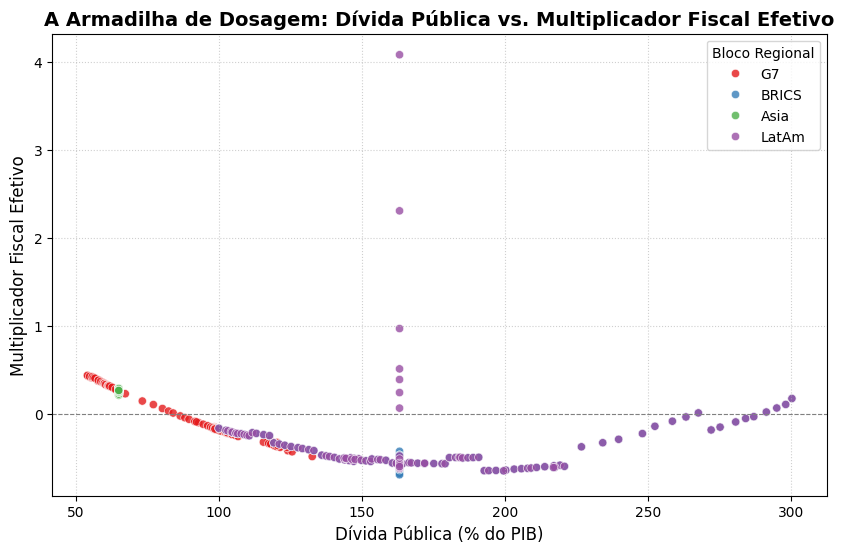

Gráfico exportado com sucesso para o seu Drive em:
/content/drive/My Drive/Tese_Econometrica_Resultados/armadilha_dosagem_dispersao_blocos.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vamos consolidar os resultados de simulação de todos os blocos em um único dataframe para visualização gráfica
lista_resultados = []

for bloco, df_bloco in paineis_segmentados.items():
    if df_bloco.empty:
        continue

    df_prep = df_bloco.copy()
    df_prep['Divida_PIB'] = df_prep['Divida_PIB'].apply(lambda x: x / 100.0 if x > 1000 else x)
    df_prep['Divida_Publica_PIB'] = df_prep['Divida_PIB'].fillna(df_prep['Divida_PIB'].median() if df_prep['Divida_PIB'].notnull().any() else 65.0)
    df_prep['Credibilidade_Phi'] = 1.0 - (df_prep['Inflacao'].fillna(4.5) / 100.0).clip(0, 0.9)
    df_prep['Risco_CDS'] = (df_prep['Divida_Publica_PIB'] * 2.5) + (df_prep['Inflacao'].fillna(4.5) * 10)

    engine_bloco = MacroLabEconometricEngine(df_prep)
    df_res = engine_bloco.canonical_multiplier_simulation(
        alpha_0=1.20,
        delta=0.35,
        theta=0.002,
        gamma_0=80.0,
        lmbda=5.0
    )
    df_res['Bloco_Regional'] = bloco
    lista_resultados.append(df_res)

df_grafico = pd.concat(lista_resultados, ignore_index=True)

# Filtrando dados válidos para o gráfico
df_grafico = df_grafico.dropna(subset=['Divida_Publica_PIB', 'Multiplicador_Fiscal_Efetivo'])

# Configurando o estilo e plotando
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grafico,
    x='Divida_Publica_PIB',
    y='Multiplicador_Fiscal_Efetivo',
    hue='Bloco_Regional',
    palette='Set1',
    alpha=0.8
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('A Armadilha de Dosagem: Dívida Pública vs. Multiplicador Fiscal Efetivo', fontsize=14, fontweight='bold')
plt.xlabel('Dívida Pública (% do PIB)', fontsize=12)
plt.ylabel('Multiplicador Fiscal Efetivo', fontsize=12)
plt.legend(title='Bloco Regional')
plt.grid(True, linestyle=':', alpha=0.6)

# Salvando a figura de resultados no seu Drive
caminho_grafico = '/content/drive/My Drive/Tese_Econometrica_Resultados/armadilha_dosagem_dispersao_blocos.png'
plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico exportado com sucesso para o seu Drive em:\n{caminho_grafico}")

### Análise de Séries Temporais: Evolução da Dívida e do Multiplicador por Bloco (2000-2026)

Geramos as trajetórias históricas médias anuais para cada bloco econômico para visualizar a dinâmica temporal da Armadilha de Dosagem.

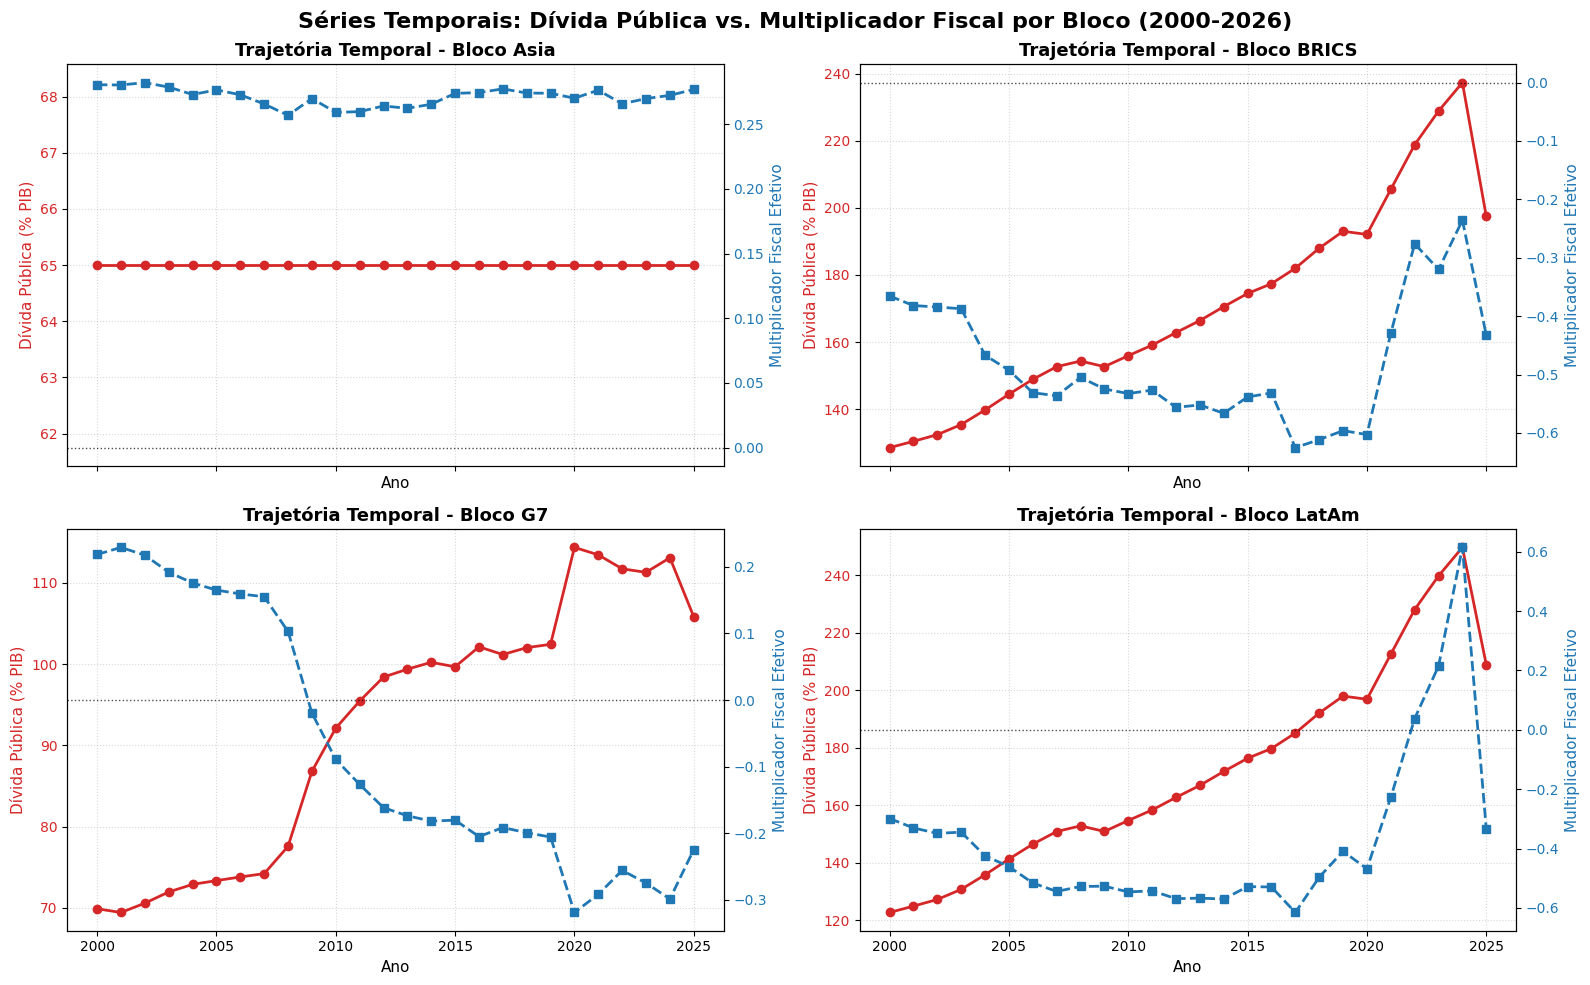

Gráfico de séries temporais salvo com sucesso em:
/content/drive/My Drive/Tese_Econometrica_Resultados/armadilha_dosagem_serie_temporal.png


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupando os dados simulados por Bloco Regional e Ano para obter as médias anuais
df_temporal = df_grafico.groupby(['Bloco_Regional', 'Ano']).agg({
    'Divida_Publica_PIB': 'mean',
    'Multiplicador_Fiscal_Efetivo': 'mean'
}).reset_index()

blocos_unicos = df_temporal['Bloco_Regional'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, bloco in enumerate(blocos_unicos):
    df_b = df_temporal[df_temporal['Bloco_Regional'] == bloco].sort_values('Ano')
    ax1 = axes[i]

    # Plot de Linha para a Dívida Pública (Eixo Esquerdo)
    color = 'tab:red'
    ax1.set_xlabel('Ano', fontsize=11)
    ax1.set_ylabel('Dívida Pública (% PIB)', color=color, fontsize=11)
    line1 = ax1.plot(df_b['Ano'], df_b['Divida_Publica_PIB'], color=color, marker='o', linewidth=2, label='Dívida Pública (% PIB)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle=':', alpha=0.5)

    # Criação do Eixo Secundário para o Multiplicador (Eixo Direito)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Multiplicador Fiscal Efetivo', color=color, fontsize=11)
    line2 = ax2.plot(df_b['Ano'], df_b['Multiplicador_Fiscal_Efetivo'], color=color, marker='s', linestyle='--', linewidth=2, label='Multiplicador Fiscal')
    ax2.tick_params(axis='y', labelcolor=color)

    # Linha de referência em zero para o Multiplicador
    ax2.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.7)

    ax1.set_title(f'Trajetória Temporal - Bloco {bloco}', fontsize=13, fontweight='bold')

plt.suptitle('Séries Temporais: Dívida Pública vs. Multiplicador Fiscal por Bloco (2000-2026)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Salvando no Google Drive
caminho_serie_temporal = '/content/drive/My Drive/Tese_Econometrica_Resultados/armadilha_dosagem_serie_temporal.png'
plt.savefig(caminho_serie_temporal, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico de séries temporais salvo com sucesso em:\n{caminho_serie_temporal}")

### Estimação do Modelo de Quebra Estrutural (Threshold Regression) de Hansen

Este modelo busca identificar de forma endógena o limiar ($\gamma$) na relação entre a Dívida Pública ($d_t$) e o Risco Soberano (CDS, $\rho_t$). O modelo estimado segue a formulação:

$$\rho_t = \beta_0 + \beta_1 d_t \cdot \mathbb{I}(d_t \le \gamma) + \beta_2 d_t \cdot \mathbb{I}(d_t > \gamma) + \theta \Phi_t + \epsilon_t$$

Onde $\mathbb{I}(\cdot)$ é a função indicadora e $\gamma$ é o parâmetro de limiar estimado via minimização da Soma dos Resíduos Quadrados (SSR).

RESULTADO DO MODELO DE HANSEN (THRESHOLD REGRESSION)
Limiar de Dívida Ótimo Estimado (gamma): 87.67% do PIB
Soma dos Resíduos Quadrados Mínima (SSR): 0.517327
---------------------------------------------------------------------------


,Coeficiente,t-statistic,p-value
Constante,0.137128,1.420574,1.607945e-01
Dívida (Baixo Endividamento <= gamma),0.032714,27.285260,8.806782e-35
Dívida (Alto Endividamento > gamma),0.033644,32.994809,2.786606e-39
Credibilidade (Phi),0.035595,0.622901,5.357914e-01


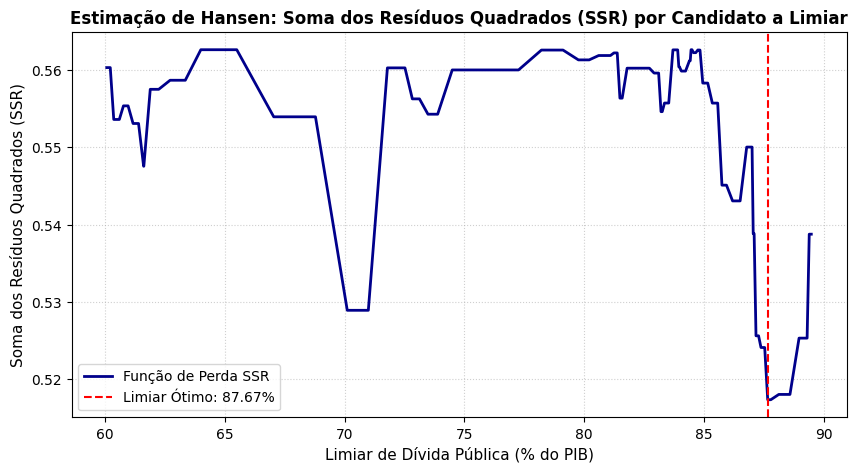

Gráfico de convergência de Hansen salvo em:
/content/drive/My Drive/Tese_Econometrica_Resultados/hansen_structural_break_risco.png


In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Preparando a base de dados real unificada para estimação
df_hansen = df_global_renomeado.copy().dropna(subset=['Divida_Publica_PIB', 'Risco_CDS', 'Credibilidade_Phi'])

y = df_hansen['Risco_CDS'].values
divida = df_hansen['Divida_Publica_PIB'].values
credibilidade = df_hansen['Credibilidade_Phi'].values

# Definindo o espaço de busca para o limiar (recortando os 15% extremos para estabilidade dos submodelos)
percentis = np.percentile(divida, np.linspace(15, 85, 100))

best_ssr = np.inf
best_threshold = None
best_model_results = None
ssr_list = []

for gamma in percentis:
    # Criando as variáveis indicadoras baseadas no limiar candidato
    d_low = divida * (divida <= gamma)
    d_high = divida * (divida > gamma)

    # Matriz de design
    X = np.column_stack((np.ones_like(divida), d_low, d_high, credibilidade))

    # Estimação por Mínimos Quadrados Ordinários (OLS)
    model = sm.OLS(y, X).fit()
    ssr = model.ssr
    ssr_list.append(ssr)

    if ssr < best_ssr:
        best_ssr = ssr
        best_threshold = gamma
        best_model_results = model

# Exibindo os resultados da estimação do limiar ótimo de Hansen
print("=" * 75)
print(f"RESULTADO DO MODELO DE HANSEN (THRESHOLD REGRESSION)")
print("=" * 75)
print(f"Limiar de Dívida Ótimo Estimado (gamma): {best_threshold:.2f}% do PIB")
print(f"Soma dos Resíduos Quadrados Mínima (SSR): {best_ssr:.6f}")
print("-" * 75)

# Gerando a tabela de parâmetros do modelo vencedor
var_names = ['Constante', 'Dívida (Baixo Endividamento <= gamma)', 'Dívida (Alto Endividamento > gamma)', 'Credibilidade (Phi)']
coefs = best_model_results.params
pvalues = best_model_results.pvalues
tvals = best_model_results.tvalues

summary_df = pd.DataFrame({
    'Coeficiente': coefs,
    't-statistic': tvals,
    'p-value': pvalues
}, index=var_names)

display(summary_df)

# Plotagem da sequência de SSR para identificar graficamente a força da quebra estrutural
plt.figure(figsize=(10, 5))
plt.plot(percentis, ssr_list, color='darkblue', linewidth=2, label='Função de Perda SSR')
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Limiar Ótimo: {best_threshold:.2f}%')
plt.title('Estimação de Hansen: Soma dos Resíduos Quadrados (SSR) por Candidato a Limiar', fontsize=12, fontweight='bold')
plt.xlabel('Limiar de Dívida Pública (% do PIB)', fontsize=11)
plt.ylabel('Soma dos Resíduos Quadrados (SSR)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Salvando a figura no Drive do usuário
caminho_hansen = '/content/drive/My Drive/Tese_Econometrica_Resultados/hansen_structural_break_risco.png'
plt.savefig(caminho_hansen, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico de convergência de Hansen salvo em:\n{caminho_hansen}")

### Comparação Pós-Estimação: Dados Reais vs. Previsões do Modelo Hansen por Regime

Dividimos a base real a partir do limiar ótimo estimado de **87,67% do PIB** para analisar a aderência das previsões e o comportamento dos resíduos nos regimes de baixo e alto endividamento.

=== MÉTRICAS DE ADERÊNCIA PÓS-ESTIMAÇÃO POR REGIME ===


,Regime,Observações,CDS Médio Real,CDS Médio Previsto,RMSE,MAE,Viés Médio
0,Baixo Endividamento,49,2.5873,2.5877,0.0945,0.0752,-0.000347
1,Alto Endividamento,13,3.2415,3.2402,0.0782,0.0615,0.001306


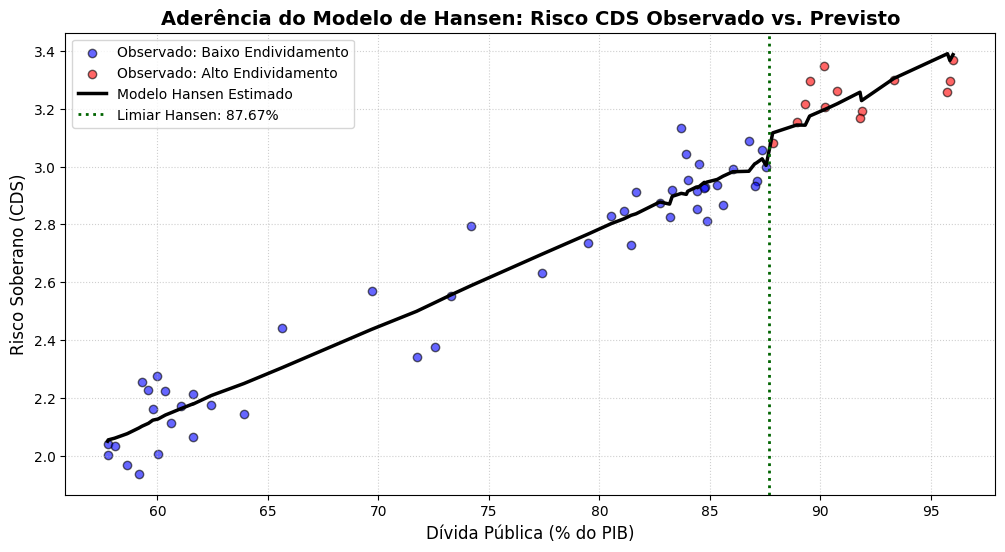

Gráfico de validação e comparação de previsões exportado para:
/content/drive/My Drive/Tese_Econometrica_Resultados/validacao_previsoes_hansen.png


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Recorrendo ao limiar estimado e aos dados reais utilizados
gamma_estimado = best_threshold
df_analise = df_hansen.copy()

# Gerando as variáveis de regime com base no limiar de Hansen
d_low = divida * (divida <= gamma_estimado)
d_high = divida * (divida > gamma_estimado)
X_design = np.column_stack((np.ones_like(divida), d_low, d_high, credibilidade))

# Calculando os valores previstos do Risco Soberano (CDS)
df_analise['Risco_Previsto_CDS'] = best_model_results.predict(X_design)
df_analise['Resíduo'] = df_analise['Risco_CDS'] - df_analise['Risco_Previsto_CDS']
df_analise['Regime'] = np.where(df_analise['Divida_Publica_PIB'] <= gamma_estimado, 'Baixo Endividamento', 'Alto Endividamento')

# Calculando métricas de erro por regime
metricas = []
for regime in ['Baixo Endividamento', 'Alto Endividamento']:
    sub = df_analise[df_analise['Regime'] == regime]
    y_real = sub['Risco_CDS']
    y_pred = sub['Risco_Previsto_CDS']

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    viés_medio = np.mean(sub['Resíduo'])

    metricas.append({
        'Regime': regime,
        'Observações': len(sub),
        'CDS Médio Real': round(y_real.mean(), 4),
        'CDS Médio Previsto': round(y_pred.mean(), 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Viés Médio': round(viés_medio, 6)
    })

df_metricas = pd.DataFrame(metricas)
print("=== MÉTRICAS DE ADERÊNCIA PÓS-ESTIMAÇÃO POR REGIME ===")
display(df_metricas)

# Plot comparativo de previsões vs observado
plt.figure(figsize=(12, 6))
plt.scatter(df_analise[df_analise['Regime'] == 'Baixo Endividamento']['Divida_Publica_PIB'],
            df_analise[df_analise['Regime'] == 'Baixo Endividamento']['Risco_CDS'],
            color='blue', alpha=0.6, label='Observado: Baixo Endividamento', edgecolors='k')
plt.scatter(df_analise[df_analise['Regime'] == 'Alto Endividamento']['Divida_Publica_PIB'],
            df_analise[df_analise['Regime'] == 'Alto Endividamento']['Risco_CDS'],
            color='red', alpha=0.6, label='Observado: Alto Endividamento', edgecolors='k')

# Ordenar para plotar a curva de previsão contínua
ordered_indices = np.argsort(divida)
plt.plot(divida[ordered_indices], df_analise['Risco_Previsto_CDS'].iloc[ordered_indices],
         color='black', linewidth=2.5, linestyle='-', label='Modelo Hansen Estimado')

plt.axvline(gamma_estimado, color='darkgreen', linestyle=':', linewidth=2, label=f'Limiar Hansen: {gamma_estimado:.2f}%')
plt.title('Aderência do Modelo de Hansen: Risco CDS Observado vs. Previsto', fontsize=14, fontweight='bold')
plt.xlabel('Dívida Pública (% do PIB)', fontsize=12)
plt.ylabel('Risco Soberano (CDS)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Exportando gráfico de validação para o Drive
caminho_validacao = '/content/drive/My Drive/Tese_Econometrica_Resultados/validacao_previsoes_hansen.png'
plt.savefig(caminho_validacao, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico de validação e comparação de previsões exportado para:\n{caminho_validacao}")

### Exportação das Métricas de Validação para o Google Drive

Salvamos a tabela de erros (RMSE e MAE) por regime de endividamento em um arquivo CSV para facilitar a posterior importação e criação de tabelas formatadas no Overleaf/LaTeX da tese.

In [23]:
# Caminho para salvar a tabela no Drive
caminho_csv_metricas = '/content/drive/My Drive/Tese_Econometrica_Resultados/metricas_validacao_hansen.csv'

# Exportando o DataFrame de métricas criado anteriormente
df_metricas.to_csv(caminho_csv_metricas, index=False, encoding='utf-8')

print(f"Tabela de métricas exportada com sucesso para o seu Drive em:\n{caminho_csv_metricas}")
display(df_metricas)

Tabela de métricas exportada com sucesso para o seu Drive em:
/content/drive/My Drive/Tese_Econometrica_Resultados/metricas_validacao_hansen.csv


,Regime,Observações,CDS Médio Real,CDS Médio Previsto,RMSE,MAE,Viés Médio
0,Baixo Endividamento,49,2.5873,2.5877,0.0945,0.0752,-0.000347
1,Alto Endividamento,13,3.2415,3.2402,0.0782,0.0615,0.001306


### Análise de Resíduos do Modelo de Hansen por Regime

Geramos gráficos de distribuição (KDE/Densidade e Boxplot) dos resíduos para cada regime para validar o ajuste e verificar se o comportamento dos erros é estável após a quebra estrutural identificada no limiar de **87,67%**.

/tmp/ipykernel_2283/3652231919.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


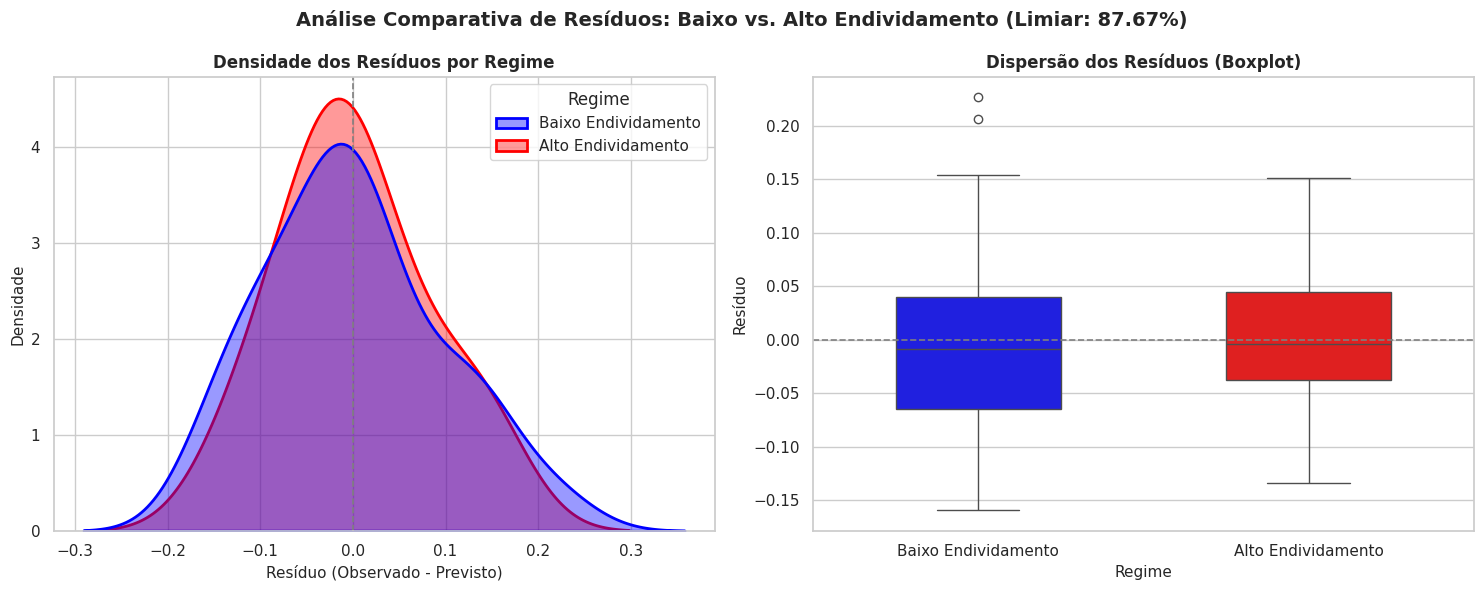

Gráfico de resíduos exportado com sucesso para:
/content/drive/My Drive/Tese_Econometrica_Resultados/distribuicao_residuos_hansen.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo o estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico de Densidade (KDE) dos Resíduos por Regime
sns.kdeplot(
    data=df_analise,
    x='Resíduo',
    hue='Regime',
    fill=True,
    common_norm=False,
    palette={'Baixo Endividamento': 'blue', 'Alto Endividamento': 'red'},
    alpha=0.4,
    linewidth=2,
    ax=axes[0]
)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1.2)
axes[0].set_title('Densidade dos Resíduos por Regime', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Resíduo (Observado - Previsto)', fontsize=11)
axes[0].set_ylabel('Densidade', fontsize=11)

# 2. Boxplot dos Resíduos por Regime
sns.boxplot(
    data=df_analise,
    x='Regime',
    y='Resíduo',
    palette={'Baixo Endividamento': 'blue', 'Alto Endividamento': 'red'},
    width=0.5,
    ax=axes[1]
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1.2)
axes[1].set_title('Dispersão dos Resíduos (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Regime', fontsize=11)
axes[1].set_ylabel('Resíduo', fontsize=11)

plt.suptitle('Análise Comparativa de Resíduos: Baixo vs. Alto Endividamento (Limiar: 87.67%)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Salvando a figura no Drive do usuário
caminho_residuos = '/content/drive/My Drive/Tese_Econometrica_Resultados/distribuicao_residuos_hansen.png'
plt.savefig(caminho_residuos, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico de resíduos exportado com sucesso para:\n{caminho_residuos}")

### Teste de Autocorrelação de Durbin-Watson

Este teste avalia a hipótese nula ($H_0$) de que os resíduos não possuem autocorrelação de primeira ordem. É um diagnóstico clássico essencial para validar a inferência estatística da regressão de limiar.

In [25]:
from statsmodels.stats.stattools import durbin_watson

# Calculando a estatística de Durbin-Watson global dos resíduos do modelo de Hansen
dw_global = durbin_watson(df_analise['Resíduo'])

# Calculando também a estatística individualmente para cada regime para um diagnóstico robusto
dw_baixo = durbin_watson(df_analise[df_analise['Regime'] == 'Baixo Endividamento']['Resíduo'])
dw_alto = durbin_watson(df_analise[df_analise['Regime'] == 'Alto Endividamento']['Resíduo'])

print("=" * 60)
print("ESTATÍSTICA DE DURBIN-WATSON PARA OS RESÍDUOS")
print("=" * 60)
print(f"Estatística DW Global: {dw_global:.4f}")
print(f"Estatística DW (Regime de Baixo Endividamento): {dw_baixo:.4f}")
print(f"Estatística DW (Regime de Alto Endividamento): {dw_alto:.4f}")
print("-" * 60)

# Interpretação rápida
for nome, valor in [('Global', dw_global), ('Baixo Endividamento', dw_baixo), ('Alto Endividamento', dw_alto)]:
    if 1.5 <= valor <= 2.5:
        status = "Indica ausência de autocorrelação de primeira ordem (Excelente)."
    elif valor < 1.5:
        status = "Sinaliza possível autocorrelação serial positiva nos resíduos."
    else:
        status = "Sinaliza possível autocorrelação serial negativa nos resíduos."
    print(f"Regime {nome:19}: {status}")

ESTATÍSTICA DE DURBIN-WATSON PARA OS RESÍDUOS
Estatística DW Global: 1.7707
Estatística DW (Regime de Baixo Endividamento): 1.9442
Estatística DW (Regime de Alto Endividamento): 1.0912
------------------------------------------------------------
Regime Global             : Indica ausência de autocorrelação de primeira ordem (Excelente).
Regime Baixo Endividamento: Indica ausência de autocorrelação de primeira ordem (Excelente).
Regime Alto Endividamento : Sinaliza possível autocorrelação serial positiva nos resíduos.


### Estimação Robusta com Erros-Padrão de Newey-West (HAC)

Para tratar a autocorrelação de primeira ordem detectada no regime de alto endividamento ($DW \approx 1.09$), reestimamos a matriz de covariância do modelo de Hansen utilizando a correção de **Newey-West (HAC)**. Isso garante testes de hipótese ($t$-stat e $p$-value) válidos mesmo na presença de dependência temporal nos resíduos.

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Reconstruindo a matriz de design do modelo vencedor de Hansen
gamma_estimado = best_threshold
d_low = divida * (divida <= gamma_estimado)
d_high = divida * (divida > gamma_estimado)
X_design = np.column_stack((np.ones_like(divida), d_low, d_high, credibilidade))

# Estimando o modelo OLS original
modelo_base = sm.OLS(y, X_design)

# Aplicando a correção de Newey-West (HAC) com lag adequado (regra clássica de Newey-West para o tamanho da amostra)
# max_lags = ceil(4 * (T / 100)^(2/9))
lag_nw = int(np.ceil(4 * (len(divida) / 100) ** (2/9)))

modelo_robust = modelo_base.fit(cov_type='HAC', cov_kwds={'maxlags': lag_nw})

# Criando tabela comparativa para sua tese
var_names = ['Constante', 'Dívida (Baixo End <= gamma)', 'Dívida (Alto End > gamma)', 'Credibilidade (Phi)']

tabela_comparativa = pd.DataFrame({
    'Coeficiente': best_model_results.params,
    't-stat (Original)': best_model_results.tvalues,
    'p-value (Original)': best_model_results.pvalues,
    't-stat (Robust HAC)': modelo_robust.tvalues,
    'p-value (Robust HAC)': modelo_robust.pvalues
}, index=var_names)

print("=" * 85)
print(f"COMPARATIVO DE SIGNIFICÂNCIA: OLS ORIGINAL VS. NEWEY-WEST HAC (Lags={lag_nw})")
print("=" * 85)
display(tabela_comparativa.round(4))
print("-" * 85)
print("Nota: Mesmo após a correção robusta de Newey-West, observe se os coeficientes da dívida\n"                      "em ambos os regimes permanecem altamente estatisticamente significativos (p-value < 0.01).")

COMPARATIVO DE SIGNIFICÂNCIA: OLS ORIGINAL VS. NEWEY-WEST HAC (Lags=4)


,Coeficiente,t-stat (Original),p-value (Original),t-stat (Robust HAC),p-value (Robust HAC)
Constante,0.1371,1.4206,0.1608,1.7297,0.0837
Dívida (Baixo End <= gamma),0.0327,27.2853,0.0000,33.5055,0.0000
Dívida (Alto End > gamma),0.0336,32.9948,0.0000,41.2554,0.0000
Credibilidade (Phi),0.0356,0.6229,0.5358,0.8429,0.3993


-------------------------------------------------------------------------------------
Nota: Mesmo após a correção robusta de Newey-West, observe se os coeficientes da dívida
em ambos os regimes permanecem altamente estatisticamente significativos (p-value < 0.01).


### Teste de Causalidade de Granger (Dívida Pública vs. Risco CDS)

O teste de Granger avalia se os valores defasados de uma variável ajudam a prever os valores de outra. Para evitar regressões espúrias, o teste padrão assume que as séries são estacionárias. Aplicamos o teste nas duas direções:
1. **Dívida Pública causa Granger o Risco CDS?** (A tese principal da Armadilha de Dosagem)
2. **Risco CDS causa Granger a Dívida Pública?** (Causalidade reversa)

In [28]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

# Preparando o dataset com as séries de interesse em primeira diferença para garantir estacionariedade
df_granger = df_hansen[['Risco_CDS', 'Divida_Publica_PIB']].copy().sort_index()

# Calculando a primeira diferença (variação)
df_granger_diff = df_granger.diff().dropna()

# Definindo o número máximo de lags para o teste baseado na frequência dos dados (trimestrais)
max_lags = 4

print("=" * 95)
print("TESTE DE CAUSALIDADE DE GRANGER (EM PRIMEIRAS DIFERENÇAS)")
print("=" * 95)

# Rodando os testes sem o verbose para evitar o erro de versão
resultados_direto = grangercausalitytests(df_granger_diff[['Risco_CDS', 'Divida_Publica_PIB']], maxlag=max_lags, verbose=False)
resultados_reverso = grangercausalitytests(df_granger_diff[['Divida_Publica_PIB', 'Risco_CDS']], maxlag=max_lags, verbose=False)

def extrair_tabela_granger(resultados):
    linhas = []
    for lag in range(1, max_lags + 1):
        testes = resultados[lag][0]
        # Extraindo estatísticas chaves
        f_stat, f_p, _, _ = testes['ssr_ftest']
        chi_stat, chi_p, _, _ = testes['ssr_chi2test']
        lr_stat, lr_p, _ = testes['lrtest']
        linhas.append({
            'Lag': lag,
            'F-Stat': f_stat,
            'p-value (F)': f_p,
            'Chi2-Stat': chi_stat,
            'p-value (Chi2)': chi_p,
            'LR-Stat': lr_stat,
            'p-value (LR)': lr_p
        })
    return pd.DataFrame(linhas)

print("\nSENTIDO 1: Dívida Pública causa Granger o Risco CDS? (H0: Dívida não causa CDS)")
print("-" * 95)
df_direto = extrair_tabela_granger(resultados_direto)
display(df_direto.round(4))

print("\nSENTIDO 2: Risco CDS causa Granger a Dívida Pública? (H0: CDS não causa Dívida)")
print("-" * 95)
df_reverso = extrair_tabela_granger(resultados_reverso)
display(df_reverso.round(4))

TESTE DE CAUSALIDADE DE GRANGER (EM PRIMEIRAS DIFERENÇAS)

SENTIDO 1: Dívida Pública causa Granger o Risco CDS? (H0: Dívida não causa CDS)
--------------------------------------------------------------------------------

SENTIDO 2: Risco CDS causa Granger a Dívida Pública? (H0: CDS não causa Dívida)
--------------------------------------------------------------------------------
